## IMPORT

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import SpectralClustering
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

## CODE

0.037886325156468975
0.037886325156468975
0.037886325156468975
0.03739270585226559
0.03739270585226559
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.036279680951093546
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
0.03879829113672762
49


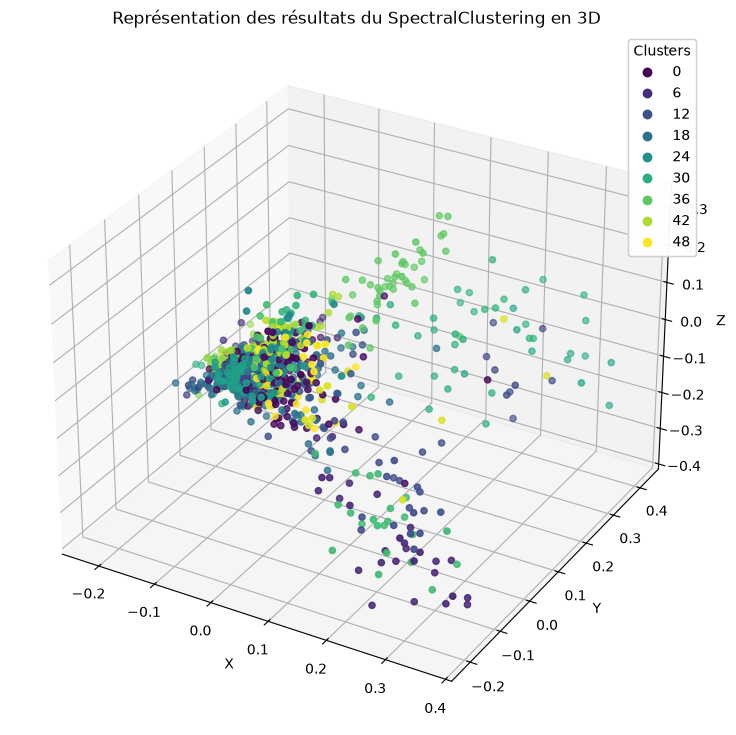

In [ ]:
try:
    df = pd.read_csv("../../Student_Clean.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

texts = df["Temoignage"].fillna("")

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)

scores = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=n,
        random_state=0,
        n_init=2,
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y) # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
    scores[f"{n}"] = score

highest_key = max(scores, key=scores.get)

scores2 = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=int(highest_key),
        random_state=0,
        n_init=n, #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y) # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
    scores2[f"{n}"] = score
    print(score)

highest_key2 = max(scores, key=scores.get)

print(highest_key2)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA

model = SpectralClustering(
    n_clusters=int(highest_key),
    random_state=0,
    n_init=int(highest_key2)
)

#Récupérer le cluster de chaque témoignage
Y = model.fit_predict(X)


#Réduire les données à 3 dimensions
pca = PCA(n_components=3)

X_3D = pca.fit_transform(X.toarray())


#Créer le graphique
fig = plt.figure(figsize=(12, 9))

axe = fig.add_subplot(111, projection="3d")


#Afficher les points
scatter = axe.scatter(
    X_3D[:, 0],
    X_3D[:, 1],
    X_3D[:, 2],
    c=Y,
)


#Nomme les axes
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

plt.title("Représentation des résultats du SpectralClustering en 3D")

#Légende des clusters
legend = axe.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

axe.add_artist(legend)


plt.show()

raise SystemExit(0)